*  DSC640-T301 Data Presentation & Visualizat (2263-1)
*  Weeks 3 & 4 Assignment - White House Logs
*  Charles Sarratt

# White House Visitor Logs (WAVES Access Records)

## Story goal
This notebook analyzes White House visitor log access records over time to identify patterns in visit volume, location mix, and meeting size.

## Audience
Operational planners and facilities coordinators responsible for staffing, scheduling, and room utilization.

## Purpose
Highlight time-based patterns that influence staffing and space planning, and provide a data-backed recommendation.

## Medium
Python-generated visual story for use in a presentation.

## Call to action
Use these trends to plan staffing and space allocation around predictable peaks, and prioritize the highest-volume locations for operational readiness.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import matplotlib.ticker as mtick

# Display settings
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 50)

# Basic plotting defaults
plt.rcParams["figure.figsize"] = (10, 5)

# Set your data folder here
DATA_DIR = Path("white_house_logs")

## Load and combine monthly datasets

Requirement check: This exercise requires at least 5 provided datasets.  
The data is split by month, so we will load multiple monthly CSVs and combine them into one table for analysis.

We will also keep a `source_file` column so we can confirm how many monthly datasets were included.

In [2]:
# Find all monthly WAVES access records files in the folder
files = sorted(DATA_DIR.glob("*WAVES-ACCESS-RECORDS*.csv"))

if len(files) == 0:
    raise FileNotFoundError(
        f"No matching CSV files found in {DATA_DIR.resolve()}. "
        "Update DATA_DIR or confirm your files are in that folder."
    )

# Load and concatenate
dfs = []
for f in files:
    tmp = pd.read_csv(f, low_memory=False)
    tmp["source_file"] = f.name
    dfs.append(tmp)

wh_logs = pd.concat(dfs, ignore_index=True)

print(f"Rows combined: {len(wh_logs):,}")
print(f"Monthly datasets included (unique files): {wh_logs['source_file'].nunique()}")
wh_logs["source_file"].value_counts().head(10)

Rows combined: 1,207,458
Monthly datasets included (unique files): 25


source_file
2023.12_WAVES-ACCESS-RECORDS.csv    122138
2023.06_WAVES-ACCESS-RECORDS.csv     94836
2022.12_WAVES-ACCESS-RECORDS.csv     87061
2023.07_WAVES-ACCESS-RECORDS.csv     84905
2023.05_WAVES-ACCESS-RECORDS.csv     83402
2023.10_WAVES-ACCESS-RECORDS.csv     83315
2023.09_WAVES-ACCESS-RECORDS.csv     70308
2023.04_WAVES-ACCESS-RECORDS.csv     69858
2023.03_WAVES-ACCESS-RECORDS.csv     69770
2023.02_WAVES-ACCESS-RECORDS.csv     45610
Name: count, dtype: int64

## Data preparation
This analysis combines 25 monthly White House visitor log datasets spanning 2021 through early 2024.

We will:
- Parse `TOA` (time of arrival) as datetime
- Create time features for day, week, and month
- Ensure `TOTAL_PEOPLE` is numeric
- Keep only rows with valid `TOA` for time-series analysis

In [3]:
# Parse datetime fields
wh_logs["TOA"] = pd.to_datetime(wh_logs["TOA"], errors="coerce")

# TOTAL_PEOPLE sometimes comes in as strings
wh_logs["TOTAL_PEOPLE"] = pd.to_numeric(wh_logs["TOTAL_PEOPLE"], errors="coerce")

# Filter to valid TOA
wh = wh_logs.dropna(subset=["TOA"]).copy()

# Time features
wh["date"] = wh["TOA"].dt.date
wh["week_start"] = wh["TOA"].dt.to_period("W").dt.start_time
wh["month_start"] = wh["TOA"].dt.to_period("M").dt.start_time

wh[["TOA", "MEETING_LOC", "TOTAL_PEOPLE", "source_file"]].head()

,TOA,MEETING_LOC,TOTAL_PEOPLE,source_file
1,2021-12-17 12:23:00,WH,27.0,2021_WAVES-ACCESS-RECORDS White House.csv
3,2021-12-19 17:25:00,WH,83.0,2021_WAVES-ACCESS-RECORDS White House.csv
6,2021-12-17 20:36:00,WH,99.0,2021_WAVES-ACCESS-RECORDS White House.csv
7,2021-12-17 20:36:00,WH,99.0,2021_WAVES-ACCESS-RECORDS White House.csv
9,2021-12-17 15:56:00,WH,52.0,2021_WAVES-ACCESS-RECORDS White House.csv


## Quick data check
We will inspect key fields and basic distributions to guide what we visualize.

In [4]:
wh[["TOA", "MEETING_LOC", "TOTAL_PEOPLE"]].describe(include="all")

,TOA,MEETING_LOC,TOTAL_PEOPLE
count,43309,30106,30104.000000
unique,NaN,5,NaN
top,NaN,WH,NaN
freq,NaN,16788,NaN
mean,2022-04-02 17:14:00.903276544,NaN,68.682866
min,2021-01-20 14:46:00,NaN,1.000000
25%,2021-09-15 10:14:00,NaN,2.000000
50%,2021-12-17 11:28:00,NaN,10.000000
75%,2022-12-06 11:54:00,NaN,73.000000
max,2023-12-25 10:58:00,NaN,1157.000000


# Visual 1 (Line): Weekly visit volume over time

This shows how overall visit volume changes week to week.  
This is useful for identifying seasonal patterns or spikes that may require staffing adjustments.

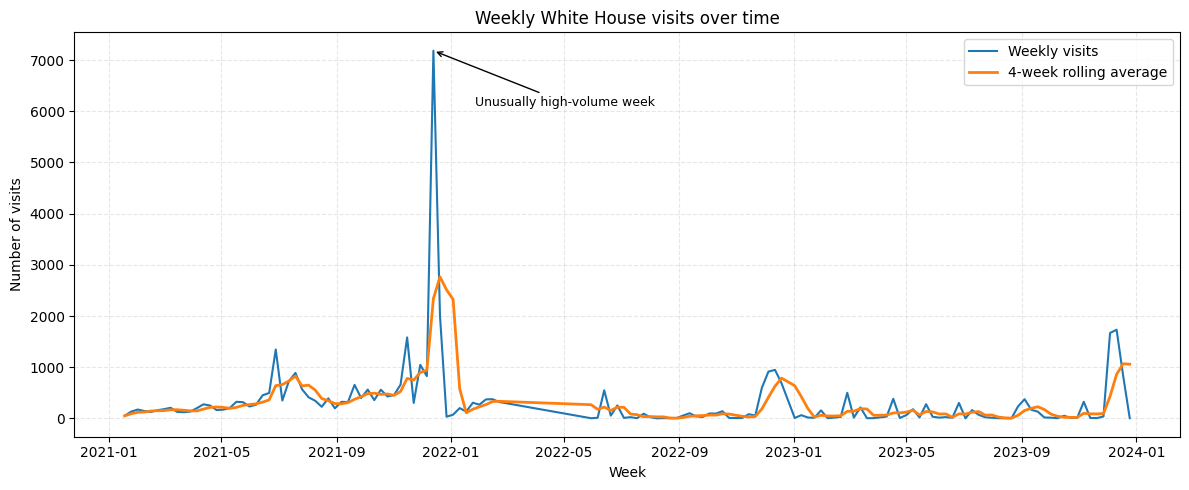

,week_start,visit_count,rolling_4wk
0,2021-01-18,50,50.000000
1,2021-01-25,133,91.500000
2,2021-02-01,173,118.666667
3,2021-02-08,144,125.000000
4,2021-02-15,126,144.000000


In [5]:
# Weekly aggregation
wh["week_start"] = wh["TOA"].dt.to_period("W").dt.start_time

weekly_visits = (
    wh.groupby("week_start")
    .size()
    .reset_index(name="visit_count")
    .sort_values("week_start")
)

# Smoothing for readability (set to False for ONLY raw weekly counts)
ADD_ROLLING_AVG = True
if ADD_ROLLING_AVG:
    weekly_visits["rolling_4wk"] = (
        weekly_visits["visit_count"]
        .rolling(window=4, min_periods=1)
        .mean()
    )

# Plot
plt.figure(figsize=(12, 5))

# Raw weekly counts
plt.plot(
    weekly_visits["week_start"],
    weekly_visits["visit_count"],
    label="Weekly visits"
)

# Rolling average
if ADD_ROLLING_AVG:
    plt.plot(
        weekly_visits["week_start"],
        weekly_visits["rolling_4wk"],
        label="4-week rolling average",
        linewidth=2
    )

plt.title("Weekly White House visits over time")
plt.xlabel("Week")
plt.ylabel("Number of visits")
plt.grid(True, linestyle="--", alpha=0.3)

# Subtle annotation for the peak week (helps explain the extreme spike)
peak = weekly_visits.loc[weekly_visits["visit_count"].idxmax()]
plt.annotate(
    "Unusually high-volume week",
    xy=(peak["week_start"], peak["visit_count"]),
    xytext=(30, -40),              # move label down and right
    textcoords="offset points",
    fontsize=9,
    ha="left",
    arrowprops=dict(arrowstyle="->", lw=1)
)

plt.legend()
plt.tight_layout()
plt.show()

weekly_visits.head()

Note: The sharp spike in late 2021 reflects an unusually high-volume week in the access logs and is preserved to accurately represent operational extremes rather than smoothed away.

# Visual 2 (Bar/Column): Top meeting locations by total visits

This identifies which locations appear most frequently in the logs, which can help prioritize operational planning.

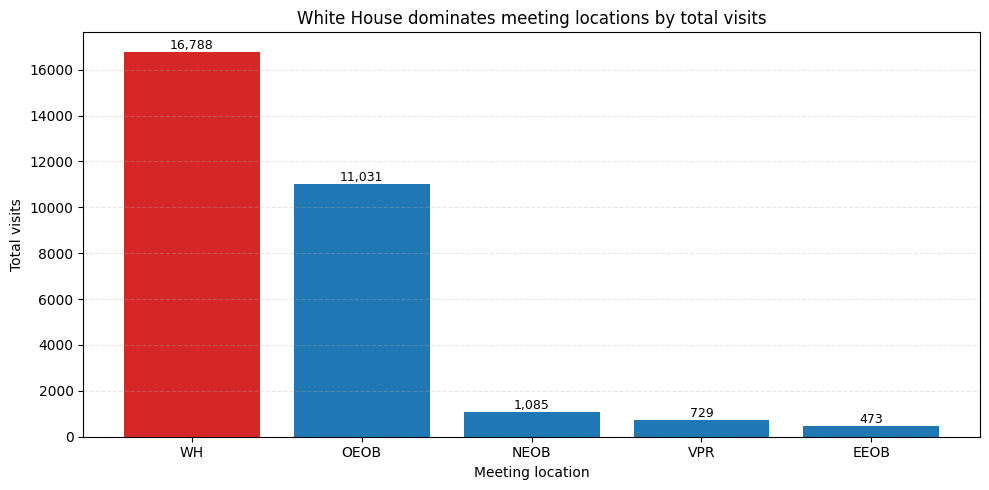

,MEETING_LOC,visit_count
4,WH,16788
2,OEOB,11031
1,NEOB,1085
3,VPR,729
0,EEOB,473


In [6]:
# Prepare data
location_totals = (
    wh.groupby("MEETING_LOC")
    .size()
    .reset_index(name="visit_count")
    .sort_values("visit_count", ascending=False)
)

top_locations = location_totals.head(10)

# Color: highlight WH
colors = [
    "tab:red" if loc == "WH" else "tab:blue"
    for loc in top_locations["MEETING_LOC"]
]

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(
    top_locations["MEETING_LOC"].astype(str),
    top_locations["visit_count"],
    color=colors
)

plt.title("White House dominates meeting locations by total visits")
plt.xlabel("Meeting location")
plt.ylabel("Total visits")

plt.grid(True, axis="y", linestyle="--", alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

top_locations

# Visual 3 (Stacked Bars with Time): Monthly visits by meeting location

This visual shows how total visit volume changes over time, broken down by meeting location.
Stacking the bars highlights both overall activity levels and which locations contribute most to monthly visit volume.
To maintain readability, the chart focuses on the most frequently used meeting locations, with all others grouped together.

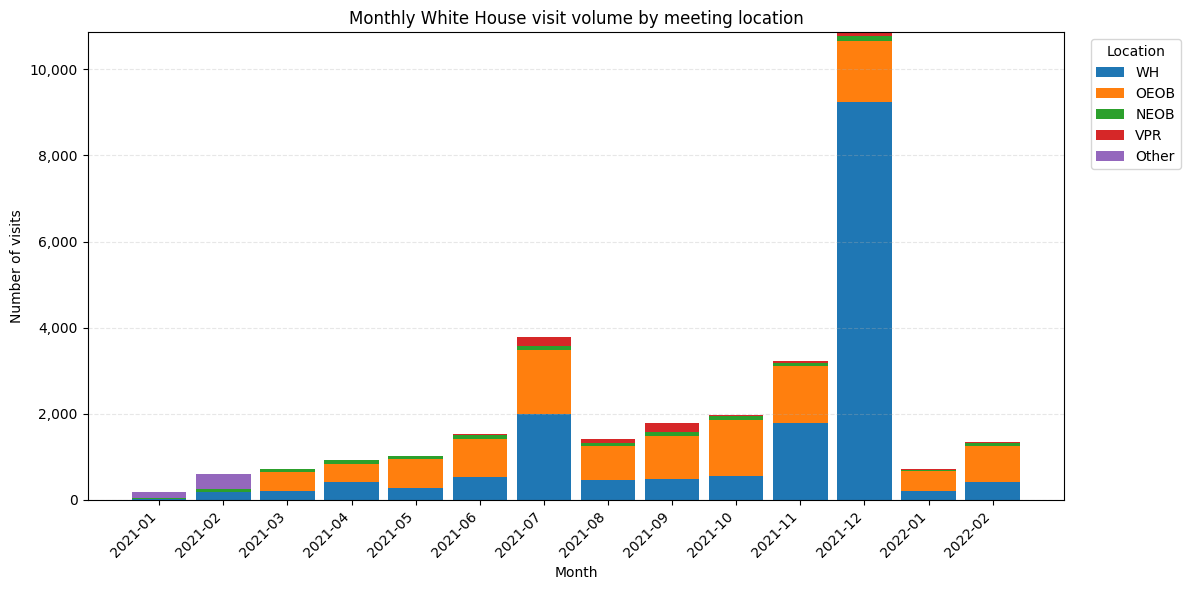

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build monthly counts by meeting location
monthly_loc = (
    wh_logs
    .assign(month_start=wh_logs["TOA"].dt.to_period("M").dt.start_time)
    .groupby(["month_start", "MEETING_LOC"])
    .size()
    .reset_index(name="visit_count")
)

# Keep only top N locations overall, group the rest into "Other"
top_n = 4
top_locs = (
    monthly_loc.groupby("MEETING_LOC")["visit_count"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index.astype(str)
    .tolist()
)

monthly_loc["MEETING_LOC_CLEAN"] = monthly_loc["MEETING_LOC"].astype(str).where(
    monthly_loc["MEETING_LOC"].astype(str).isin(top_locs),
    other="Other"
)

monthly_loc = (
    monthly_loc
    .groupby(["month_start", "MEETING_LOC_CLEAN"])["visit_count"]
    .sum()
    .reset_index()
)

pivot_monthly = (
    monthly_loc
    .pivot(index="month_start", columns="MEETING_LOC_CLEAN", values="visit_count")
    .fillna(0)
    .sort_index()
)

# Order columns by overall size so stacks are consistent
pivot_monthly = pivot_monthly[pivot_monthly.sum().sort_values(ascending=False).index]

# Categorical x positions (prevents needle-bars)
x = np.arange(len(pivot_monthly))
month_labels = pivot_monthly.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(pivot_monthly))
for col in pivot_monthly.columns:
    ax.bar(x, pivot_monthly[col].values, bottom=bottom, label=col, width=0.85)
    bottom += pivot_monthly[col].values

ax.set_title("Monthly White House visit volume by meeting location")
ax.set_xlabel("Month")
ax.set_ylabel("Number of visits")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Show fewer x labels so it is readable
step = max(1, len(month_labels) // 12)  # about 12 ticks
ax.set_xticks(x[::step])
ax.set_xticklabels(month_labels[::step], rotation=45, ha="right")

ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Visual 4 (Scatterplot with Time): Daily average group size

This visual shows how meeting group size varies over time.  
It helps identify periods with unusually large groups that may impact screening, space, and staffing.

To improve readability, the y-axis is capped to focus on typical daily group sizes while still retaining all data points in the analysis. Extreme outliers are discussed in the ethical considerations.

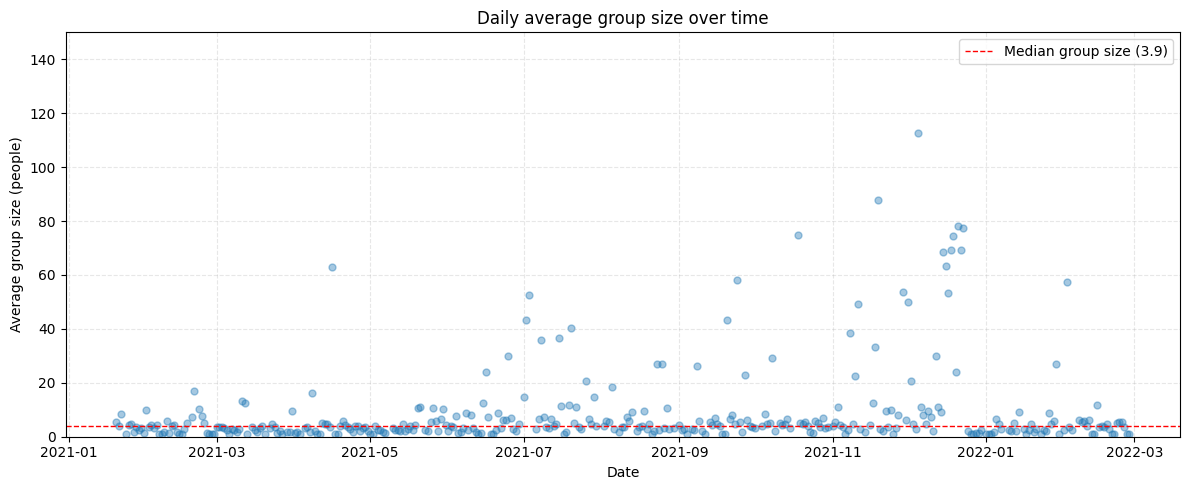

In [8]:
wh["TOA"] = pd.to_datetime(wh["TOA"], errors="coerce")
wh["TOTAL_PEOPLE"] = pd.to_numeric(wh["TOTAL_PEOPLE"], errors="coerce")

daily_avg_group = (
    wh.dropna(subset=["TOA", "TOTAL_PEOPLE"])
      .assign(date=wh["TOA"].dt.date)
      .groupby("date", as_index=False)["TOTAL_PEOPLE"]
      .mean()
      .rename(columns={"TOTAL_PEOPLE": "avg_group_size"})
)
daily_avg_group["date"] = pd.to_datetime(daily_avg_group["date"])

plt.figure(figsize=(12, 5))

plt.scatter(
    daily_avg_group["date"],
    daily_avg_group["avg_group_size"],
    alpha=0.4,
    s=25
)

median_val = daily_avg_group["avg_group_size"].median()
plt.axhline(
    y=median_val,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Median group size ({median_val:.1f})"
)

plt.title("Daily average group size over time")
plt.xlabel("Date")
plt.ylabel("Average group size (people)")

# Cap y-axis to improve readability
plt.ylim(0, 150)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Note: The y-axis is capped to improve readability. Extreme outliers are discussed in the narrative but excluded from the visible range.

# Visual 5 (Step Chart): Cumulative visits over time

This cumulative step chart shows how total visit volume builds over time.  
The step format emphasizes periods of accelerated growth versus slower accumulation, helping identify shifts in visitation patterns that may require operational planning adjustments.

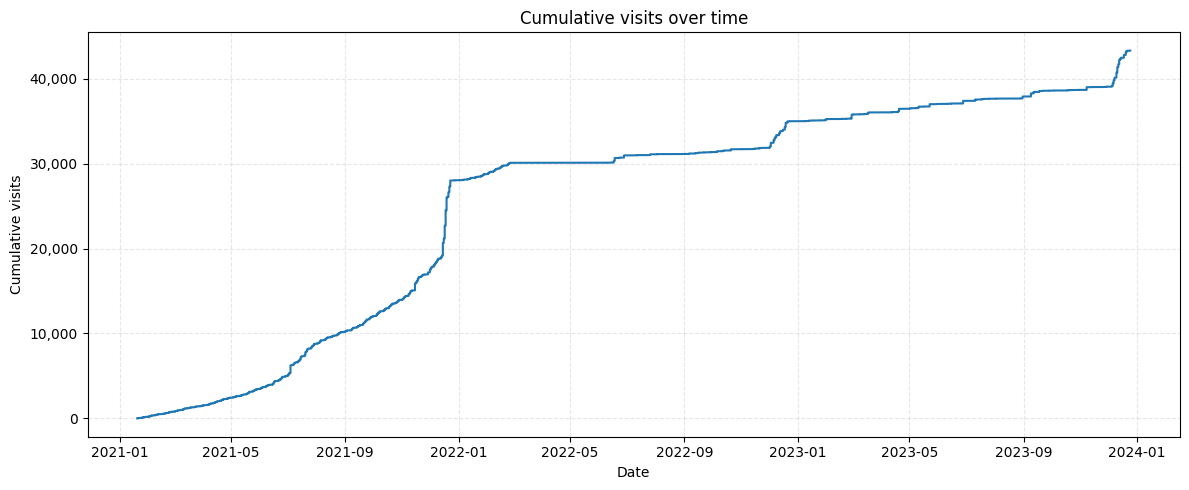

,date,visit_count,cumulative_visits
0,2021-01-20,2,2
1,2021-01-21,24,26
2,2021-01-22,23,49
3,2021-01-24,1,50
4,2021-01-25,35,85


In [9]:
daily_visits = (
    wh.groupby("date")
      .size()
      .reset_index(name="visit_count")
)
daily_visits["date"] = pd.to_datetime(daily_visits["date"])
daily_visits = daily_visits.sort_values("date")
daily_visits["cumulative_visits"] = daily_visits["visit_count"].cumsum()

plt.figure(figsize=(12, 5))
plt.step(daily_visits["date"], daily_visits["cumulative_visits"], where="post")
plt.title("Cumulative visits over time")
plt.xlabel("Date")
plt.ylabel("Cumulative visits")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

daily_visits.head()

# Visual 6 (Line): Monthly visit totals with 3-month moving average

This visual smooths month-to-month variability to highlight the broader trend in visit volume over time.  
Using a rolling average reduces short-term noise and makes longer-term changes in visitation patterns easier to interpret.

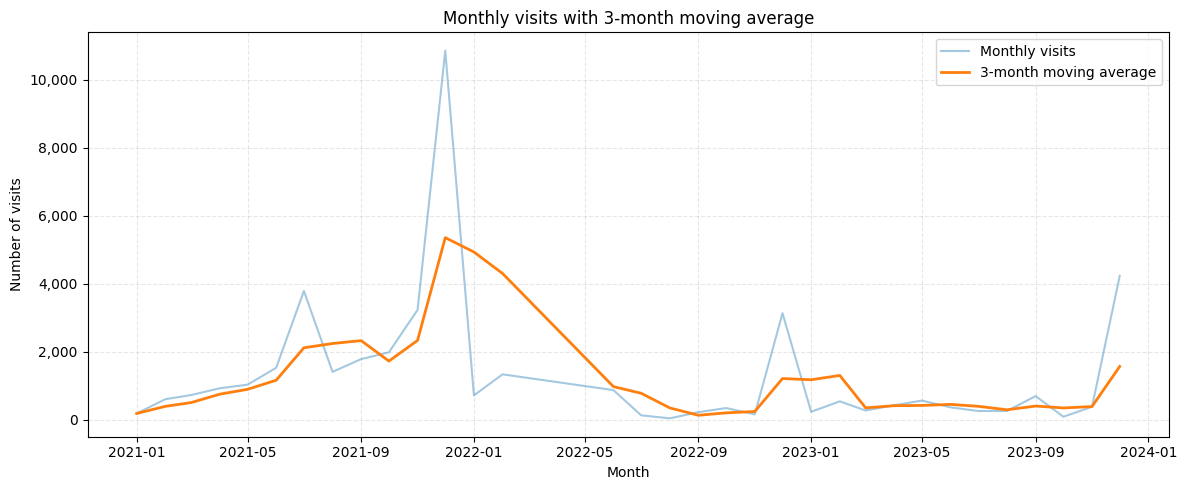

,month_start,visit_count,ma_3
0,2021-01-01,183,183.000000
1,2021-02-01,603,393.000000
2,2021-03-01,726,504.000000
3,2021-04-01,926,751.666667
4,2021-05-01,1030,894.000000


In [10]:
monthly_visits = (
    wh.groupby("month_start")
      .size()
      .reset_index(name="visit_count")
      .sort_values("month_start")
)

monthly_visits["ma_3"] = (
    monthly_visits["visit_count"]
    .rolling(window=3, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_visits["month_start"],
    monthly_visits["visit_count"],
    label="Monthly visits",
    alpha=0.4
)

plt.plot(
    monthly_visits["month_start"],
    monthly_visits["ma_3"],
    label="3-month moving average",
    linewidth=2
)

plt.title("Monthly visits with 3-month moving average")
plt.xlabel("Month")
plt.ylabel("Number of visits")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

monthly_visits.head()

## Findings summary (for presentation)

Key takeaways to support operational planning:

- Weekly visit volume fluctuates, with distinct peaks that suggest the need for planning buffers.
- A small number of meeting locations account for the majority of visit activity.
- While location mix varies month to month, core locations consistently dominate overall volume.
- Average group size is generally stable but shows occasional spikes that may impact screening, space, and staffing needs.
- Cumulative and smoothed monthly trends make long-term changes in visit patterns easier to communicate.

## Recommended call to action

Use historical visit patterns to inform staffing and space allocation decisions:

- Schedule additional staffing coverage during historically high-volume periods.
- Prioritize operational readiness at the highest-volume meeting locations, as they drive most activity.
- Use spikes in group size as triggers for enhanced screening, space planning, and staffing adjustments.

## Ethical considerations

This analysis uses publicly available White House visitor log data that has already been anonymized at the source. No personally identifiable information is interpreted beyond aggregate visit counts and group sizes.

Several data preparation choices were made and are disclosed transparently:
- Rows with missing or invalid visit timestamps (TOA) were excluded to ensure accurate time-based analysis.
- Group size outliers were present and were addressed in Visual 4 by capping the y-axis to preserve interpretability while retaining the original data.
- All visuals use aggregated counts rather than individual-level records to reduce the risk of misinterpretation.

Because the dataset is administrative in nature, visit counts may reflect operational logging practices rather than intent or importance of visits. Results should be interpreted as indicators of volume patterns, not behavioral conclusions.